# HOMEWORK 12

In this homework you are going to inspect the GTSDB (German Traffic Sign Detection Benchmark) dataset. The dataset contains images of various classes of traffic signs used in Germany (and the whole EU). The objective of this homework is to go through the steps described below and to implement the necessary code.

At the end, as usual, there will be a couple of questions for you to answer. In addition, the last section of this homework is optional and, if you chose to do it, you'll earn extra point :-)

In [19]:
import os
import cv2
import numpy as np
import pandas as pd
import csv
from collections import Counter
from collections import defaultdict

from matplotlib import pyplot as plt
plt.rcParams['figure.figsize'] = [15, 10]

### Step 0

Go to the GTSRB dataset official site ([link](https://benchmark.ini.rub.de/gtsrb_dataset.html)) to learn more about the dataset.

### Step 1

Download the dataset ([link](https://www.kaggle.com/meowmeowmeowmeowmeow/gtsrb-german-traffic-sign)) and unzip it.

### Step 2

For this homework, you will be working with the training set. Check out the `Train.csv`, open it and see what it contains. Load the dataset and plot random samples.

Number of training samples: 39209


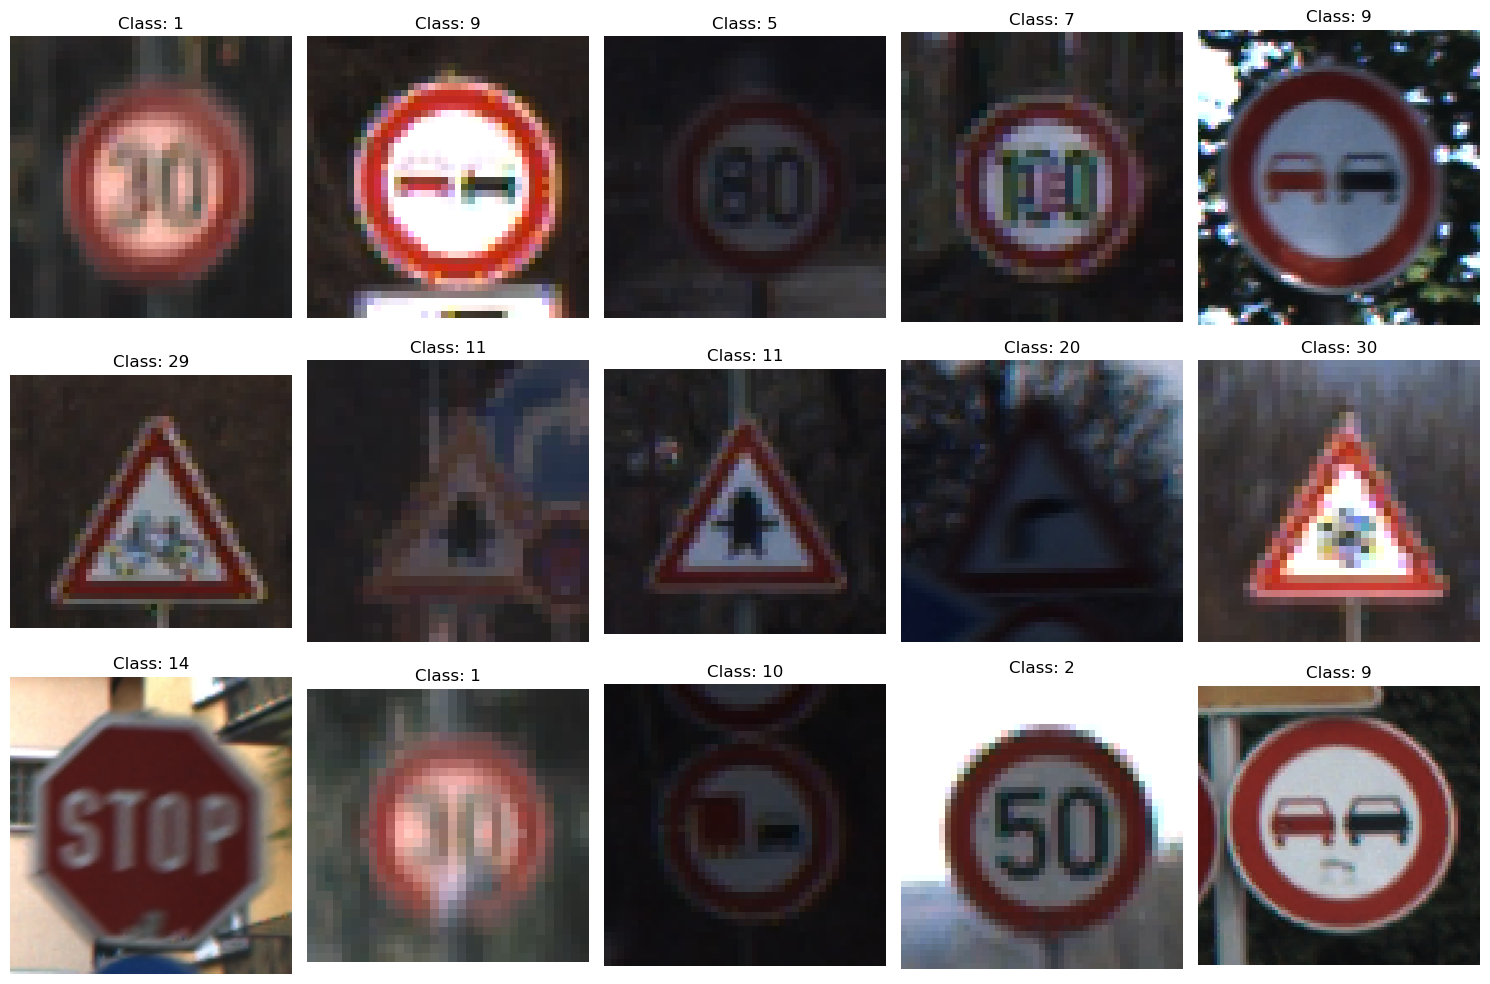

In [20]:
# Load the training labels
rootpath = 'data/GTSRB/Training/Images' # Path to the dataset location
images = [] # images
labels = [] # corresponding labels
paths = []   # image paths
# loop over all 42 classes
for c in range(0,43):
    prefix = rootpath + '/' + format(c, '05d') + '/' # subdirectory for class
    gtFile = open(prefix + 'GT-'+ format(c, '05d') + '.csv') # annotations file
    gtReader = csv.reader(gtFile, delimiter=';') # csv parser for annotations file
    next(gtReader) # skip header
    # loop over all images in current annotations file
    for row in gtReader:
        img_path = prefix + row[0]
        try:
            img = plt.imread(img_path)
            images.append(img)  # the 1st column is the filename
            labels.append(int(row[7]))  # the 8th column is the label
            paths.append(img_path)
        except FileNotFoundError:
            print(f"Warning: File not found {img_path}")
    gtFile.close()

# Number of training samples (amount of samples in data)
num_samples = len(images)
print("Number of training samples:", num_samples)

# Show random data samples
for ii in range(15):
    # Get random index
    idx = np.random.randint(0, num_samples)
    # Load image
    img = cv2.imread(paths[idx])
    # Convert image to RGB
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    # Show image
    plt.subplot(3, 5, ii + 1)
    plt.imshow(img)
    plt.title(f"Class: {labels[idx]}")
    plt.axis('off')

plt.tight_layout()
plt.show()

### Step 3

Inspect the dataset by computing and plotting the per-class histogram.

In [21]:
# Extract class identifiers
# Hint: Check the csv 
ids = labels  # Extract class identifiers
hist = Counter(ids)  # Compute the per-class histogram

Compute the per class histogram. You can use any approach you want (e.g. `numpy`). It's also worth looking at the `Counter` function from the `collections` module ([link](https://docs.python.org/3/library/collections.html#collections.Counter)) ;-)

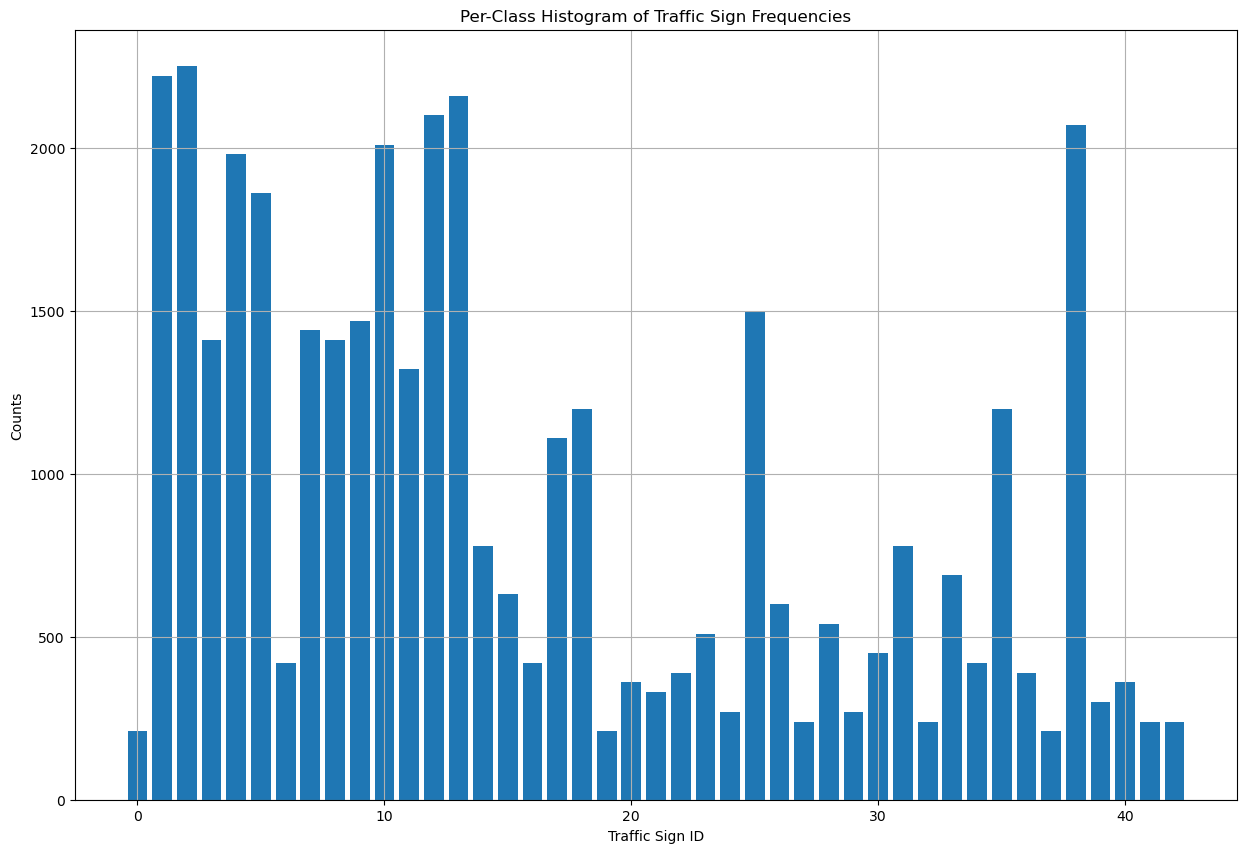

In [22]:
#Display histogram
plt.bar(hist.keys(), hist.values()), plt.grid(True)
plt.xlabel('Traffic Sign ID'), plt.ylabel('Counts')
plt.title('Per-Class Histogram of Traffic Sign Frequencies')
plt.show()

### Questions

Please answer the following questions:
* Do you consider the dataset to be balanced? If so, why? If not, why?
** Nope. There is a big difference between some classes 
* Are there any classes that are (significantly) over-represented or under-represeneted?
** There are representatives for both variants 

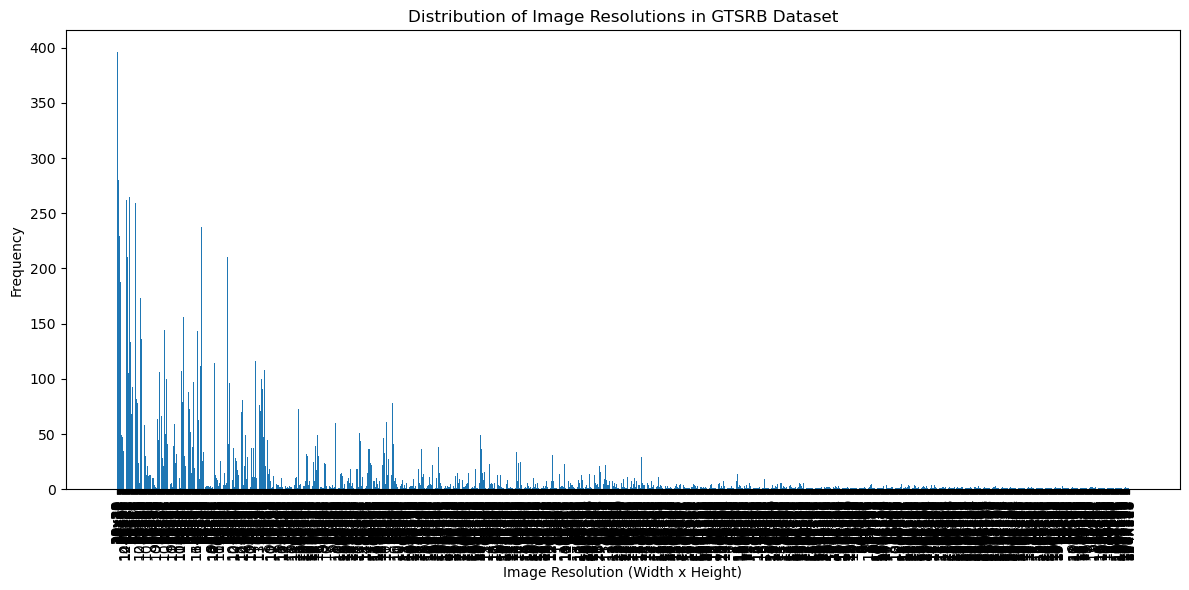

In [23]:
#Analyze resolution distribution
resolutions = [ (img.shape[1], img.shape[0]) for img in images ]  # (width, height)
res_counter = Counter(resolutions)

# Prepare data for plotting
res_labels = [f"{w}x{h}" for (w, h) in res_counter.keys()]
res_counts = list(res_counter.values())

# Plot histogram of resolutions
plt.figure(figsize=(12, 6))
plt.bar(res_labels, res_counts)
plt.xticks(rotation=90)
plt.xlabel("Image Resolution (Width x Height)")
plt.ylabel("Frequency")
plt.title("Distribution of Image Resolutions in GTSRB Dataset")
plt.tight_layout()
plt.show()

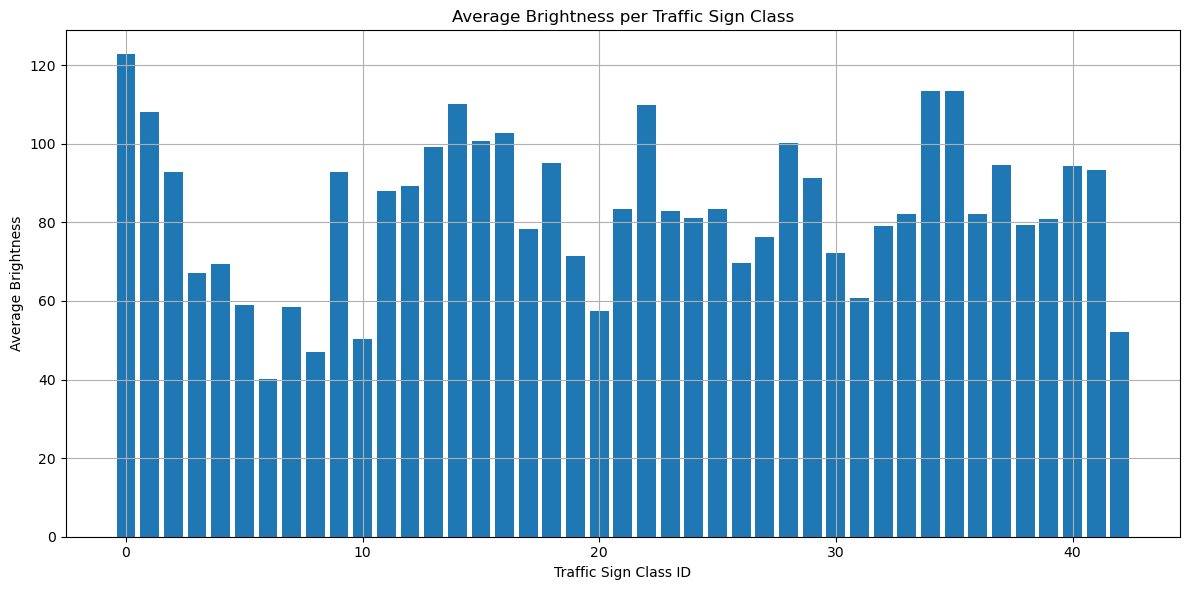

In [24]:
# Compute brightness per image and group by class
brightness_by_class = defaultdict(list)

for img, label in zip(paths, labels):
    image = cv2.imread(img)
    if image is not None:
        gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
        brightness = np.mean(gray)
        brightness_by_class[label].append(brightness)

# Compute average brightness per class
avg_brightness = {cls: np.mean(vals) for cls, vals in brightness_by_class.items()}

# Sort and plot
sorted_classes = sorted(avg_brightness.keys())
sorted_brightness = [avg_brightness[cls] for cls in sorted_classes]

plt.figure(figsize=(12, 6))
plt.bar(sorted_classes, sorted_brightness)
plt.xlabel("Traffic Sign Class ID")
plt.ylabel("Average Brightness")
plt.title("Average Brightness per Traffic Sign Class")
plt.grid(True)
plt.tight_layout()
plt.show()

### Optional

Perform a further analysis on the dataset and draw some conclusion from it.

Hint 1: Unlike MNIST or CIFAR10, this dataset contains images with various spatial resolutions. Is there anything we can tell about the resolution distribution?
Hint 2: What about the brightness distribution? Are there classes there are significantly more bright than others?

Azhidko: Based on resolution distribution data, normalization is required - resizing. Also based on brightness distribution data requires normalization - convert to grayscale and normalize (divide to 255). 